In [1]:
import os
os.environ['USE_PYGEOS'] = '0'
import sys
import numpy
import pandas
pandas.options.mode.chained_assignment = None  # default='warn'
from datetime import datetime, timedelta
import pytz
import geopandas
import dask_geopandas
import json
from glob import glob
import time

sys.path.insert(1, os.path.abspath("../.."))
from qtree_index import nestedgrid, mortoncurve
from vectorstore import vectorstore

import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt

# Initialize a dataset

In [2]:
%%time
dataset = 'kaggle_wildfire'
collection_id = 'vector-kaggle-wildfire'

# Stac collection title
collection_title = '1.88 Million US Wildfires'

# Stac collection description
description = """IMPORTANT: THE GEOMETRY COLUMN OF THIS DATASET IS A CIRCLE CENTERED AT THE POSITION GIVEN IN "LONGITUDE" AND "LATITUDE" COLUMNS WITH AN AREA GIVEN IN THE "FIRE_SIZE" COLUMN. IT IS NOT THE ACTUAL EXTEND OF THE FIRE.

Context:
This data publication contains a spatial database of wildfires that occurred in the United States from 1992 to 2015. It is the third update of a publication originally generated to support the national Fire Program Analysis (FPA) system. The wildfire records were acquired from the reporting systems of federal, state, and local fire organizations. The following core data elements were required for records to be included in this data publication: discovery date, final fire size, and a point location at least as precise as Public Land Survey System (PLSS) section (1-square mile grid). The data were transformed to conform, when possible, to the data standards of the National Wildfire Coordinating Group (NWCG). Basic error-checking was performed and redundant records were identified and removed, to the degree possible. The resulting product, referred to as the Fire Program Analysis fire-occurrence database (FPA FOD), includes 1.88 million geo-referenced wildfire records, representing a total of 140 million acres burned during the 24-year period.

Acknowledgements:
These data were collected using funding from the U.S. Government and can be used without additional permissions or fees. If you use these data in a publication, presentation, or other research product please use the following citation:

Short, Karen C. 2017. Spatial wildfire occurrence data for the United States, 1992-2015 [FPA_FOD_20170508]. 4th Edition. Fort Collins, CO: Forest Service Research Data Archive. https://doi.org/10.2737/RDS-2013-0009.4

https://www.kaggle.com/datasets/rtatman/188-million-us-wildfires"""

# Parquet file custom metadata
custom_meta_content = {'About': description}

dt_col = 'timestamp'
geom_col = 'geometry'  # Needs to be called 'geometry'
id_col = 'FOD_ID'
dimension_values = {}

# temporal_keys = [] #['year']
# temporal_partitions = [] #['year']

max_level = 26
target_level = 14
max_depth = 14
max_inflation = 100 #None
target_rows = 2e5

grid = nestedgrid.World(4326)
# Create or initialize an existing GeoDN vectorstore
vs = vectorstore.Vectorstore(
    dataset=dataset,
    collection_id=collection_id,
    dimension_values=dimension_values,
    grid=grid,
    dt_col=dt_col,
    geom_col=geom_col,
    id_col=id_col,
    max_level=max_level,
    target_level=target_level,
    max_depth=max_depth,
    max_inflation=max_inflation,
    target_rows=target_rows,
    custom_meta_content=custom_meta_content,
    verbose=True,
)

vs.write_metadata()
vs.read_metadata()

filepath = '/data/vector/kaggle_wildfire/gdf_kaggle_wildfire.parquet'

# def make_geometry_table(df):
#     # FIRE_SIZE is in acres. 
#     # So let's approximate the geometry by buffereing the point to the area of the FIRE_SIZE (ellipse in WGS84)
#     gdf = geopandas.GeoDataFrame(df, geometry=geopandas.points_from_xy(df.LONGITUDE, df.LATITUDE), crs="EPSG:4326")
#     # Switch projection to Pseudo Merkator (almost conformal projection to preserve angles)
#     gdf = gdf.to_crs("EPSG:3857")
#     # Mercator scale factor (for areas use the square)
#     scale_factor = numpy.cos(gdf['LATITUDE'] / 180. * numpy.pi)
#     # Acres to meters
#     gdf['radius'] = numpy.sqrt(gdf['FIRE_SIZE'] * 4046.8564224 / numpy.pi) / scale_factor
#     # Buffer to create a circle
#     gdf['geometry'] = gdf['geometry'].buffer(gdf['radius'])
#     del gdf['radius']
#     # Switch back to WGS84
#     gdf = gdf.to_crs("EPSG:4326")
#     return gdf

# parquet_path = '/data/vector/kaggle_wildfire/kaggle_wildfire.parquet'
# df = pandas.read_parquet(parquet_path)
# gdf = make_geometry_table(df)
# gdf.to_parquet(filepath)

gdf_complete = geopandas.read_parquet(filepath)
#gdf_complete[dt_col] = datetime(2022, 5, 12, tzinfo=pytz.utc)

assert(~gdf_complete[[id_col, dt_col]].duplicated().any())

gdf_complete.tail(2)

CPU times: total: 9.92 s
Wall time: 13.5 s


,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,LONGITUDE,OWNER_CODE,OWNER_DESCR,STATE,COUNTY,FIPS_CODE,FIPS_NAME,Shape,timestamp,geometry
1880463,1831008,300251694,SFO-2015TXLFDX594491,NONFED,ST-NASF,ST/C&L,USTXTXS,Texas A & M Forest Service,TXLFDX,Local Fire Department,...,-94.947366,14.0,MISSING/NOT SPECIFIED,TX,Gregg,183,Gregg,b'\x00\x01\xad\x10\x00\x00\x1cv\x95\xa4\xa1\xb...,2015-12-31 00:00:00+00:00,"POLYGON ((-94.94717 32.43941, -94.94718 32.439..."
1880464,1801139,300213917,W-688210,FED,DOI-WFMI,BIA,USNMZUA,Zuni Agency,NMZUA,Zuni Agency,...,-108.782890,2.0,BIA,NM,None,None,None,b'\x00\x01\xad\x10\x00\x00`\x97\xa8\xde\x1a2[\...,2015-12-31 00:00:00+00:00,"POLYGON ((-108.78267 35.08119, -108.78268 35.0..."


In [3]:
vars(vs)

{'grid': World(4326),
 'morton': <qtree_index.mortoncurve.Morton at 0x2811d584950>,
 'valid_range': <POLYGON ((180 -90, 180 90, -180 90, -180 -90, 180 -90))>,
 'dataset': 'kaggle_wildfire',
 'collection_id': 'vector-kaggle-wildfire',
 'temporal_levels': [],
 'dimension_values': {},
 'vectorstore_directory': 'data/vectorstore/',
 'dataset_directory': 'data/vectorstore/kaggle_wildfire',
 'grid_directory': 'data/vectorstore/kaggle_wildfire/grid=World(4326)',
 'geoparquet_directory': 'data/vectorstore/kaggle_wildfire/grid=World(4326)/geoparquet',
 'index_directory': 'data/vectorstore/kaggle_wildfire/grid=World(4326)/index',
 'dt_col': 'timestamp',
 'key_col': '_root',
 'idx_col': '_idx',
 'geom_col': 'geometry',
 'id_col': 'FOD_ID',
 'idx_box_col': 'idx_bounds',
 'geom_area_col': '_geom_area',
 'geom_length_col': '_geom_length',
 'primary_keys': ['timestamp', 'FOD_ID'],
 'max_level': 26,
 'target_level': 14,
 'max_depth': 14,
 'max_inflation': 100,
 'target_rows': 200000.0,
 'row_group_siz

# Chunked successive ingestion

In [4]:
%%time
n_chunks = 1
for i, chunk in enumerate(numpy.array_split(gdf_complete, n_chunks)):
    print('Chunk', i)
    vs.partial_upload(
        chunk,
        defrag=False,
        index=False,
        geometry_area=False,
        geometry_length=False,
    )

C:\Users\2D1245897\software\openeo\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'GeoDataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'GeoDataFrame.transpose' instead.
  return bound(*args, **kwds)
C:\Users\2D1245897\software\openeo\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'GeoDataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'GeoDataFrame.transpose' instead.
  return bound(*args, **kwds)


Chunk 0
df_root 1880465
Time for indexing the root of each unique geometry in seconds 22.221
distributed over 13 partitions
Time for creating partitions in seconds 21.827
Time for writing GeoDataFrame to GeoParquet partitions 64.289
CPU times: total: 30.4 s
Wall time: 1min 27s


In [5]:
%%time
vs.unify_schemas()

Time for unify_schemas 10.949
CPU times: total: 6.62 s
Wall time: 10.9 s


In [6]:
%%time
vs.defrag()

Time for defragging 58.833
CPU times: total: 27.6 s
Wall time: 58.8 s


In [7]:
%%time
vs.repartition({})

level 1
source partition          target partition          records stay    records move   
level 2
source partition          target partition          records stay    records move   
level 3
source partition          target partition          records stay    records move   
level 4
source partition          target partition          records stay    records move   
level 5
source partition          target partition          records stay    records move   
level 6
source partition          target partition          records stay    records move   
level 7
source partition          target partition          records stay    records move   
level 8
source partition          target partition          records stay    records move   
level 9
source partition          target partition          records stay    records move   
level 10
source partition          target partition          records stay    records move   
level 11
source partition          target partition          records stay    re

In [8]:
%%time
vs.defrag()

Time for defragging 54.638
CPU times: total: 23.3 s
Wall time: 54.6 s


In [9]:
# %%time
# vs.reindex({})

# Visualize spatial partitions

In [10]:
%%time
ddf = dask_geopandas.read_parquet(vs.geoparquet_directory)
ddf

CPU times: total: 15.6 ms
Wall time: 157 ms


,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,LOCAL_FIRE_REPORT_ID,LOCAL_INCIDENT_ID,FIRE_CODE,FIRE_NAME,ICS_209_INCIDENT_NUMBER,ICS_209_NAME,MTBS_ID,MTBS_FIRE_NAME,COMPLEX_NAME,FIRE_YEAR,DISCOVERY_DATE,DISCOVERY_DOY,DISCOVERY_TIME,STAT_CAUSE_CODE,STAT_CAUSE_DESCR,CONT_DATE,CONT_DOY,CONT_TIME,FIRE_SIZE,FIRE_SIZE_CLASS,LATITUDE,LONGITUDE,OWNER_CODE,OWNER_DESCR,STATE,COUNTY,FIPS_CODE,FIPS_NAME,Shape,timestamp,geometry,_root,grid,spatial_partition
npartitions=13,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
,int64,int64,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,int64,float64,int64,object,float64,object,float64,float64,object,float64,object,float64,float64,float64,object,object,object,object,object,object,"datetime64[us, UTC]",geometry,object,category[known],category[known]
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


<Axes: >

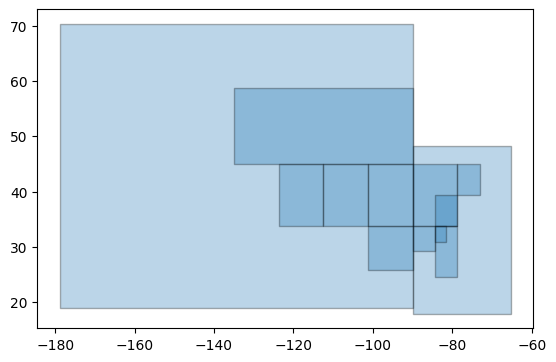

In [11]:
ddf.spatial_partitions.plot(edgecolor='k', alpha=0.3)

# Upload to COS and register in STAC

In [12]:
import dotenv
dotenv.load_dotenv()

# S3 access key
access_key_id = os.getenv('claimed_access_key_id', '')
# S3 access secret
secret_access_key = os.getenv('claimed_secret_access_key', '')
# S3 access url
endpoint_url = os.getenv('claimed_endpoint_url', '')
# S3 access url
private_endpoint_url = os.getenv('claimed_private_endpoint_url', '')
# S3 bucket
bucket = os.getenv('claimed_bucket', '')

# STAC url
stac_url = os.getenv('stac_url', 'https://stac-fastapi-pgstac-nasageospatial-dev.cash.sl.cloud9.ibm.com')
# STAC certificate
certificate = os.getenv('certificate', '/opt/app-root/src/ca.cert.txt')

#vs._connect_s3(access_key_id, secret_access_key, endpoint_url, bucket)

In [13]:
# vs.access_key_id = access_key_id
# vs.secret_access_key = secret_access_key
# vs.endpoint_url = endpoint_url
# vs.bucket = bucket
# vs._connect_s3(access_key_id, secret_access_key, endpoint_url, bucket)

# storage_urls = vs.remote_fs.glob(os.path.join(vs.remote_geoparquet_directory, '**.parquet').replace('\\', '/'))
# storage_urls

In [14]:
# # GeoDN username
# geodn_username = os.getenv('geodn_username', '')
# # GeoDN password
# geodn_password = os.getenv('geodn_password', '')
# # GeoDN url
# GEODN_URL = os.getenv('GEODN_URL', "https://openeo-geodn-nasageospatial-dev.cash.sl.cloud9.ibm.com/openeo/1.1.0/")

In [15]:
stac_json_folder = os.path.join(vs.grid_directory, 'stac').replace('\\','/')

bbox = vs.grid.valid_bounds_wgs84
df = pandas.read_parquet(vs.geoparquet_directory, columns=[vs.dt_col])
dt_start = df[vs.dt_col].min()
dt_end = df[vs.dt_col].max()

vs.to_stac_collection(
    stac_url,
    vs.collection_id,
    collection_title,
    stac_json_folder,
    certificate,
    bbox,
    dt_start,
    dt_end,
    description,
    access_key_id=access_key_id,
    secret_access_key=secret_access_key,
    endpoint_url=endpoint_url,
    bucket=bucket,
    remote_vectorstore_directory=None,
)

In [16]:
%%time
# Upload to COS
upload_type = "replace_all" #"replace_all" "replace_partition" "add" "stac_items_only"
vs.to_cos(
    upload_type=upload_type,
    stac_url=stac_url,
    collection_id=vs.collection_id,
    collection_title=collection_title,
    stac_json_folder=stac_json_folder,
    certificate=certificate,
    access_key_id=access_key_id,
    secret_access_key=secret_access_key,
    endpoint_url=endpoint_url,
    bucket=bucket,
    remote_vectorstore_directory=None,
    temporal_partitions=None,
    spatial_partitions=None,
)

uploading to remote_path claimed-test/vectorstore/kaggle_wildfire/grid=World(4326)/geoparquet/spatial_partition=0q0/cced961be27f4ab7b232654aba3fc15d.parquet
schema.names ['OBJECTID', 'FOD_ID', 'FPA_ID', 'SOURCE_SYSTEM_TYPE', 'SOURCE_SYSTEM', 'NWCG_REPORTING_AGENCY', 'NWCG_REPORTING_UNIT_ID', 'NWCG_REPORTING_UNIT_NAME', 'SOURCE_REPORTING_UNIT', 'SOURCE_REPORTING_UNIT_NAME', 'LOCAL_FIRE_REPORT_ID', 'LOCAL_INCIDENT_ID', 'FIRE_CODE', 'FIRE_NAME', 'ICS_209_INCIDENT_NUMBER', 'ICS_209_NAME', 'MTBS_ID', 'MTBS_FIRE_NAME', 'COMPLEX_NAME', 'FIRE_YEAR', 'DISCOVERY_DATE', 'DISCOVERY_DOY', 'DISCOVERY_TIME', 'STAT_CAUSE_CODE', 'STAT_CAUSE_DESCR', 'CONT_DATE', 'CONT_DOY', 'CONT_TIME', 'FIRE_SIZE', 'FIRE_SIZE_CLASS', 'LATITUDE', 'LONGITUDE', 'OWNER_CODE', 'OWNER_DESCR', 'STATE', 'COUNTY', 'FIPS_CODE', 'FIPS_NAME', 'Shape', 'timestamp', 'geometry', '_root']
schema.types [DataType(int64), DataType(int64), DataType(string), DataType(string), DataType(string), DataType(string), DataType(string), DataType(s

In [17]:
vs.stac_json_folder_submitted

'data/vectorstore/kaggle_wildfire/grid=World(4326)/stac/submitted'

In [18]:
vs.stac_url

'https://stac-fastapi-sqlalchemy-nasageospatial-dev.cash.sl.cloud9.ibm.com'

In [19]:
vs.collection_id

'vector-kaggle-wildfire'